# Class 7: Unsupervised Learning II

### Agenda
1. Unsupervised Learning Use-case
2. Cluster Characterization

## 0. Import Packages

In [85]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from IPython.display import display, Image

import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

np.random.seed(0)

In [86]:
import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

## Use-case: Clustering Heart Disease Patient Data
We are going to look at anonymized patients who have been diagnosed with heart disease. Patients with similar characteristics might respond to the same treatments, and doctors would benefit from learning about the outcomes of patients similar to those they are treating. The data we are analyzing comes from the V.A. Medical Center in Long Beach, CA.

This example is adapted from: https://www.kaggle.com/code/darkaster/clustering-heart-disease-patient-data#1.-Targeting-treatment-for-heart-disease-patients

**Note:** You saw this dataset on the previous class!

Here's what we know about this dataset:

- contains 303 rows (observations)
- 14 columns

And some documentation we found about each column:

1. **Age:** age in years
2. **Sex:** sex (1 = male; 0 = female)
3. **Cp:** chest pain type
   - Value 1: typical angina
   - Value 2: atypical angina
   - Value 3: non-anginal pain
   - Value 4: asymptomatic
4. **Trestbps:** resting blood pressure (in mm Hg on admission to the hospital)
5. **Chol:** serum cholesterol in mg/dl
6. **Fbs:** fasting blood sugar > 120 mg/dl (1 = true; 0 = false)
7. **Restecg:** resting electrocardiographic results
   - Value 0: normal
   - Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
   - Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria
8. **Thalach:** maximum heart rate achieved
9. **Exang:** exercise induced angina (1 = yes; 0 = no)
10. **Oldpeak:** ST depression induced by exercise relative to rest
11. **Slope:** the slope of the peak exercise ST segment
    - Value 1: upsloping
    - Value 2: flat
    - Value 3: downsloping
12. **Ca:** number of major vessels (0-3) colored by flourosopy
13. **Thal:** 
    - 3 = normal
    - 6 = fixed defect
    - 7 = reversible defect
14. **Diagnosed:** diagnosis of heart disease (angiographic disease status)
    - Value 0: < 50% diameter narrowing
    - Value 1: > 50% diameter narrowing

In [87]:
# Loading the data
data = pd.read_csv('https://raw.githubusercontent.com/Hospital-Da-Luz-Learning-Health/MLCatolica24/main/Aula%204%20-%20Unsupervised%20Learning/data/heart_disease.csv')

In [88]:
# how the dataframe looks like
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,Diagnosed
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [89]:
# check shape of the dataframe
data.shape

(303, 14)

In [90]:
# check missing values
data.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           4
thal         2
Diagnosed    0
dtype: int64

In [91]:
# we can remove the rows with missing values (for simplicity)
data = data.dropna()
data.shape

(297, 14)

In [92]:
X_data = data.drop('Diagnosed', axis=1)

When we have several variables in different scales it is important to standardize them!

We'll use the StandardScaler function to standardize the data in a way that each variable will have mean = 0 and standard deviation = 1.

In [93]:
# Standardize the features 
scaler = StandardScaler()
data_standardized = scaler.fit_transform(X_data)

We analyze the silhouette score

In [94]:
# Define the range of k values to test
k_values = range(2, 11)
silhouette_scores = []
labels_list = []

In [95]:
# Compute K-Means clustering and calculate silhouette score for each k
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0)
    labels = kmeans.fit_predict(data_standardized)
    labels_list.append(labels)
    score = silhouette_score(data_standardized, labels)
    silhouette_scores.append(score)

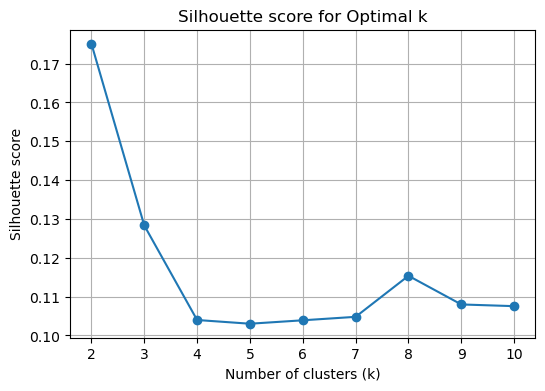

In [96]:
# Plotting the Elbow Method
plt.figure(figsize=(6, 4))
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
plt.title('Silhouette score for Optimal k')
plt.grid(True)
plt.show()

**Note:** In real datasets, the silhouette scores can be very "bad".

**But, can we somehow visualize the clusters?**

Okay, it's not a 2D problem, however, there are some ways that we can use to visualize the clusters. When we deal with high-dimensional data, visualizing the clusters becomes challenging because we cannot easily plot data in more than 2 or 3 dimensions. This makes it difficult to interpret the results of clustering algorithms.

To address this issue, we can use dimensionality reduction techniques to project high-dimensional data into lower dimensions while preserving the important structure and relationships in the data.


## 2. Cluster Characterization

This is an essential step in the clustering analysis process for several reasons:

1. Understanding Cluster Composition
2. Validating Clusters
3. Identifying Key Features
4. Improving Interpretability
5. Identifying Patterns and Insights
6. Guiding Future Actions

In [101]:
# Add cluster labels to the original dataframe
kmeans = KMeans(n_clusters=2, random_state=0)
cluster_labels_k2 = kmeans.fit_predict(data_standardized)

data['Cluster'] = cluster_labels_k2

In [115]:
# Compute the percentage of diabetic cases (Outcome == 1) per cluster
cluster_summary = data.groupby('Cluster')['Diagnosed'].agg(['count', 'sum'])

cluster_summary['Percentage_heart_disease'] = (cluster_summary['sum'] / cluster_summary['count']) * 100
cluster_summary.T

Cluster,0,1
count,184.000000,113.000000
sum,37.000000,100.000000
Percentage_heart_disease,20.108696,88.495575


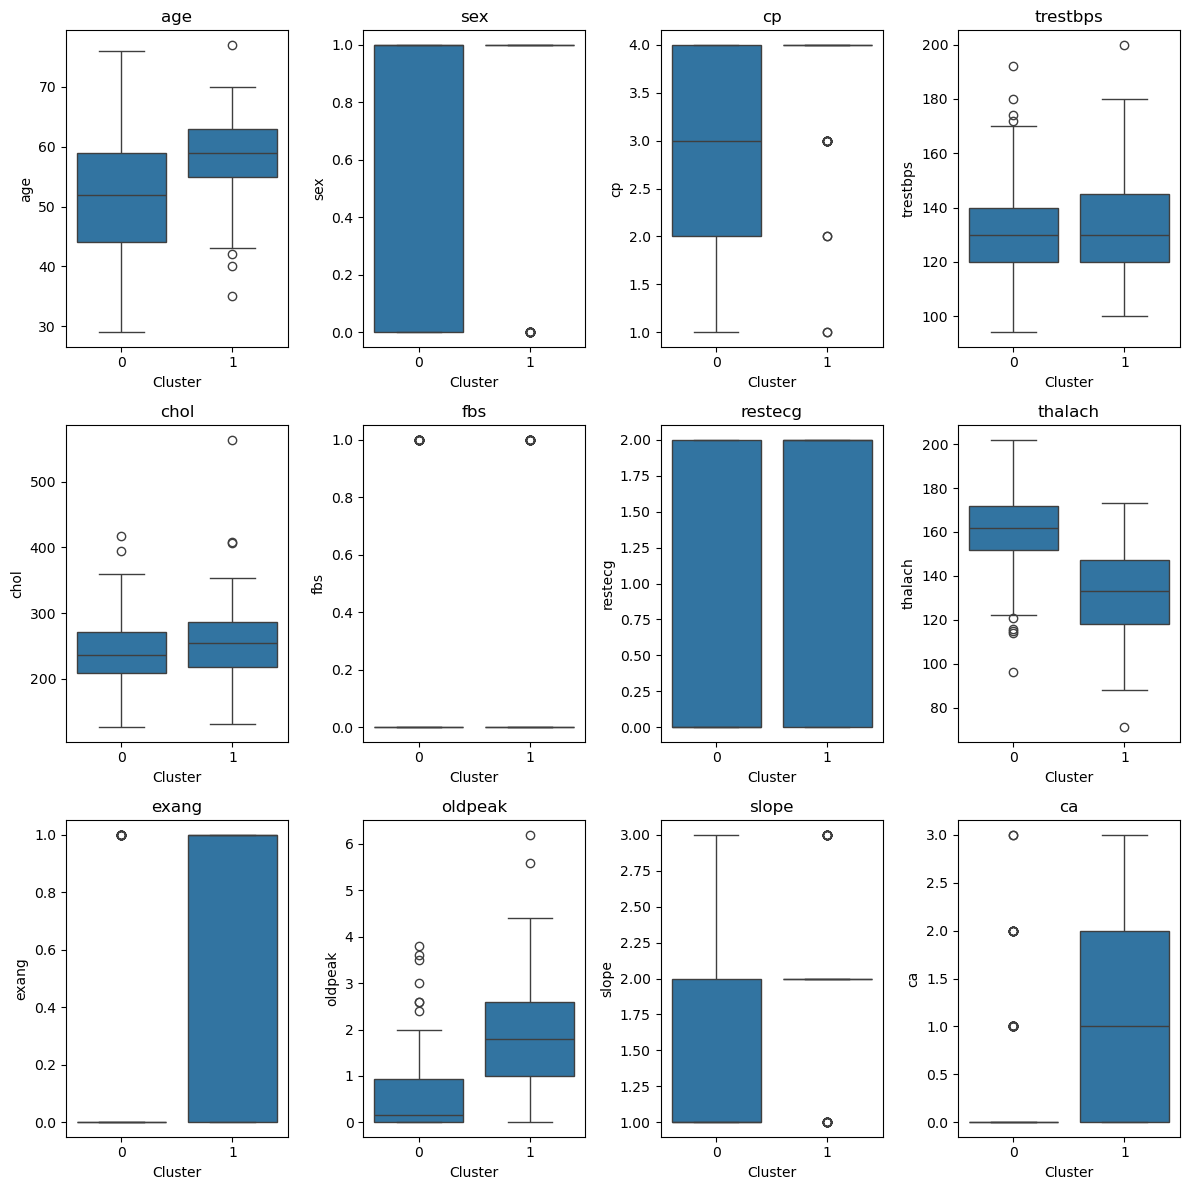

In [112]:
variables = data.drop(columns=['Diagnosed', 'Cluster']).columns

ncols = 4
nrows = (len(variables) + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4*nrows))
axes = axes.flatten()

for ax, var in zip(axes, variables):
    sns.boxplot(data=data, x='Cluster', y=var, ax=ax)
    ax.set_title(var)

plt.tight_layout()
plt.show()